## Task #3. Blackbody radiation and heat capacity

Plot the Planck 'Black Body radiation' spectrum *B*(λ, *T*) for several temperatures, and also plot Einstein's model of molar heat capacity of solids vs temperature for various atomic crystals such as gold, copper, iron.

In [1]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy
from ipywidgets import interact_manual

In [2]:
# Planck Spectrum Graphing Calc
Irradiance = []
MinTemp = 4000  # k
MaxTemp = 6000  # k
NumberOfMesurements = 3  # num
MinWavelength = 1  # nm
MaxWaveLength = 2500  # nm
NumberOfWaveLengthChecks = 1000  # num

h = 6.626 * 10**-34  # plancks constant
c = 2.998 * 10**8  # speed of light
k = 1.381 * 10**-23  # Boltzmann's constant

Temp = numpy.linspace(MinTemp, MaxTemp, NumberOfMesurements)
Waves = numpy.linspace(MinWavelength, MaxWaveLength, NumberOfWaveLengthChecks)
for x in range(len(Temp)):
    T = Temp[x]
    RadAtT = []
    for y in range(len(Waves)):
        W = Waves[y] * 10**-9
        # Rewritten as e^-x/(1-e^-x) instead of 1/(e^x-1) so it decays
        # to 0 smoothly at short wavelengths instead of overflowing e^x.
        Exponent = h * c / (W * k * T)
        Radiance = (
            ((2 * h * c**2) / (W**5))
            * (numpy.e ** (-Exponent) / (1 - numpy.e ** (-Exponent)))
            * 10**-9
        )
        RadAtT.append(Radiance)
    Irradiance.append(RadAtT)

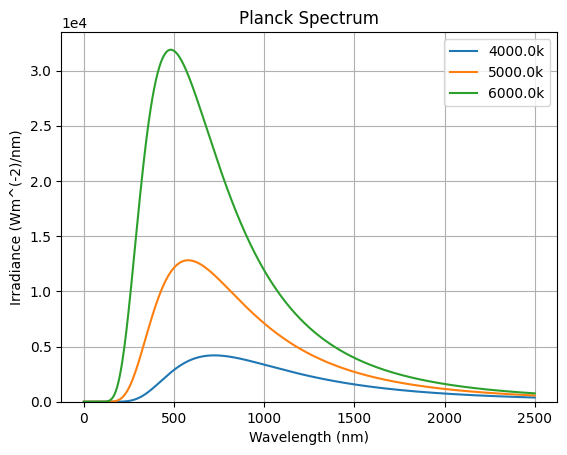

In [3]:
# Planck Spectrum Graphing Graph
fig, ax = plt.subplots(1, 1)

ax.grid(True, "both", "both")

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Irradiance (Wm^(-2)/nm)")
ax.set_title("Planck Spectrum")
for x in range(len(Temp)):
    ax.plot(Waves, Irradiance[x], label=f"{round(Temp[x],2)}k")
ax.legend()
plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
plt.ylim(bottom=0)
plt.show()

In [4]:
# Einsteins Heat Capacity Calculations


def Formula(EinTemp, N, Temp, k):
    r = EinTemp / Temp
    # Rewritten as e^-r/(1-e^-r)**2 instead of e^r/(e^r-1)**2 so it decays to
    # 0 smoothly at low T instead of overflowing e^r into NaN.
    ExpNegR = numpy.e ** (-r)
    return 3 * N * k * (r**2) * (ExpNegR / (1 - ExpNegR) ** 2)


h = 6.626 * 10**-34  # plancks constant
c = 2.998 * 10**8  # speed of light
k = 1.381 * 10**-23  # Boltzmann's constant
MaxTemp = 800  # k
MinTemp = 1  # k
NumberOfMesurements = 1000  # num
N = (
    5 * 6.0221408 * 10**23
)  # number of atoms in 5 mol, using Avogadro's constant (mol^-1)

Temp = numpy.linspace(MinTemp, MaxTemp, NumberOfMesurements)
Au = Formula(210, N, Temp, k)  # gold Einstein temperature (k)
Cu = Formula(230, N, Temp, k)  # copper Einstein temperature (k)
Fe = Formula(330, N, Temp, k)  # iron Einstein temperature (k)
Ti = Formula(257, N, Temp, k)  # titanium Einstein temperature (k)
Al = Formula(290, N, Temp, k)  # aluminium Einstein temperature (k)
Si = Formula(620, N, Temp, k)  # silicon Einstein temperature (k)
Diamond = Formula(2230, N, Temp, k)  # diamond Einstein temperature (k)

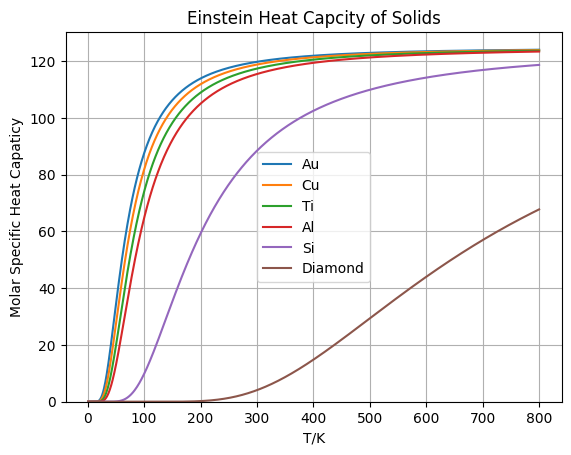

In [5]:
# Einstein Graphing
fig, ax = plt.subplots(1, 1)

ax.grid(True, "both", "both")

ax.set_xlabel("T/K")
ax.set_ylabel("Molar Specific Heat Capaticy")
ax.set_title("Einstein Heat Capcity of Solids")
ax.plot(Temp, Au, label="Au")
ax.plot(Temp, Cu, label="Cu")
ax.plot(Temp, Ti, label="Ti")
ax.plot(Temp, Al, label="Al")
ax.plot(Temp, Si, label="Si")
ax.plot(Temp, Diamond, label="Diamond")
plt.ylim(bottom=0)

ax.legend()
plt.show()